# Customer Churn Prediction
## Predicting which telecom customers will leave using Machine Learning

**Dataset:** Telco Customer Churn (7,043 customers, 21 features)  
**Problem:** Binary Classification — Will a customer churn? (Yes/No)  
**Goal:** Identify at-risk customers so business can take retention action

In [78]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score , precision_score , recall_score , f1_score , confusion_matrix , classification_report

In [79]:
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

## Phase 1: Data Exploration

In [80]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [81]:
df.shape

(7043, 21)

In [82]:
df['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [83]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [84]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


## Phase 2: Data Cleaning
TotalCharges column contains spaces — converting to numeric and handling nulls

In [85]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print(df['TotalCharges'].isnull().sum())

11


In [86]:
# Fill missing TotalCharges with median
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

# Confirm no more nulls
print(df['TotalCharges'].isnull().sum()) 
print(df['TotalCharges'].dtype) 

0
float64


## Phase 3: Exploratory Data Analysis

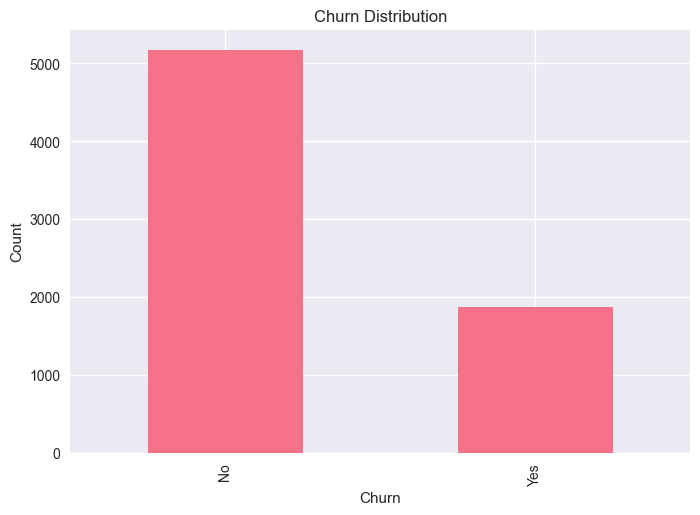

In [87]:
df['Churn'].value_counts().plot(kind='bar')
plt.title('Churn Distribution')
plt.xlabel('Churn')
plt.ylabel('Count')
plt.show()

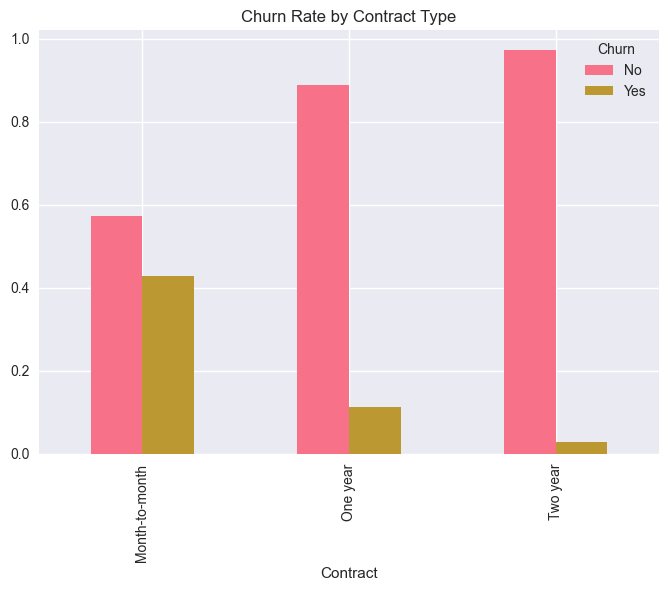

In [88]:
df.groupby('Contract')['Churn'].value_counts(normalize=True).unstack().plot(kind='bar')
plt.title('Churn Rate by Contract Type')
plt.show()

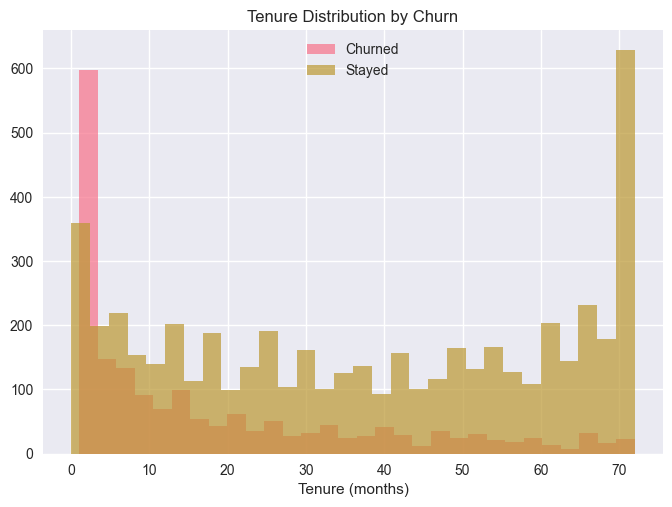

In [89]:
df[df['Churn']=='Yes']['tenure'].hist(bins=30, alpha=0.7, label='Churned')
df[df['Churn']=='No']['tenure'].hist(bins=30, alpha=0.7, label='Stayed')
plt.legend()
plt.title('Tenure Distribution by Churn')
plt.xlabel('Tenure (months)')
plt.show()

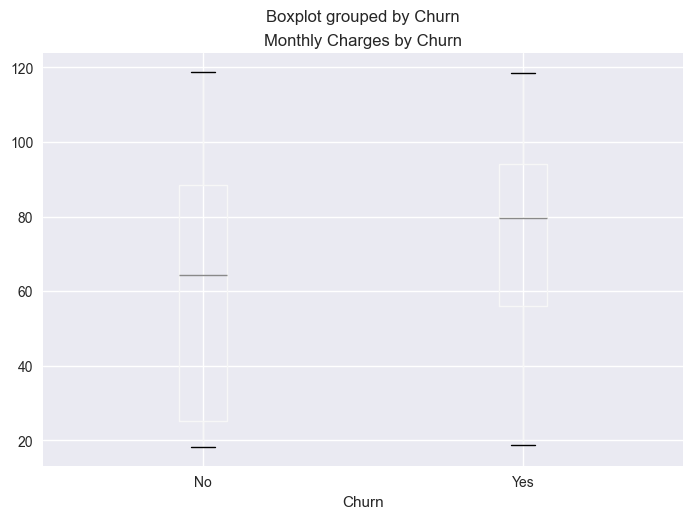

In [90]:
df.boxplot(column='MonthlyCharges', by='Churn')
plt.title('Monthly Charges by Churn')
plt.show()

## EDA Key Findings

1. Imbalanced Dataset
   - 73% customers stayed (5174), 27% churned (1869)
   - Will use F1 score as primary metric instead of accuracy

2. Contract Type is Strongest Churn Predictor
   - Month-to-month customers have highest churn rate
   - Two-year contract customers have lowest churn rate
   - Business insight: incentivize customers to switch to longer contracts

3. New Customers Churn the Most
   - Majority of churn happens within first 10 months
   - Customers who stay beyond 10 months tend to stay long term
   - Business insight: focus retention efforts on newly acquired customers

4. Churned Customers Pay Higher Monthly Charges
   - Churned customers have higher median monthly charges
   - Price sensitivity is a major driver of churn
   - Business insight: offer discounts to high-paying at-risk customers

## Phase 4: Feature Engineering & Preprocessing

In [91]:
df.drop('customerID', axis=1, inplace=True)

In [92]:
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

In [93]:
print(df.select_dtypes(include='object').columns.tolist())

['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [94]:
# Binary columns — Label Encoding (Yes/No → 1/0)
binary_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 
               'PaperlessBilling']

le = LabelEncoder()
for col in binary_cols:
    df[col] = le.fit_transform(df[col])

# Multi-category columns — One Hot Encoding
multi_cols = ['MultipleLines', 'InternetService', 'OnlineSecurity', 
              'OnlineBackup', 'DeviceProtection', 'TechSupport', 
              'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod']

df = pd.get_dummies(df, columns=multi_cols, drop_first=True)

# Confirm
print(df.shape)
print(df.dtypes.value_counts())

(7043, 31)
bool       21
int64       8
float64     2
Name: count, dtype: int64


In [95]:
# Convert bool columns to int
df = df.astype({col: int for col in df.select_dtypes(include='bool').columns})

# Confirm
print(df.dtypes.value_counts())

int64      29
float64     2
Name: count, dtype: int64


## Phase 5: Model Training & Evaluation

In [96]:
X = df.drop('Churn', axis=1)
y = df['Churn']

In [97]:
X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                    test_size=0.2, 
                                    random_state=42,
                                    stratify=y) 

In [98]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [99]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("Churn rate in train:", y_train.mean())
print("Churn rate in test:", y_test.mean())

X_train shape: (5634, 30)
X_test shape: (1409, 30)
Churn rate in train: 0.2653532126375577
Churn rate in test: 0.2654364797728886


In [103]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'),
    'Decision Tree': DecisionTreeClassifier(max_depth=5, random_state=42, class_weight='balanced'),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced'),
    'XGBoost': XGBClassifier(random_state=42, scale_pos_weight=3)
}

In [104]:
results = []

for name, model in models.items():
    # Use scaled data for Logistic Regression, unscaled for others
    if name == 'Logistic Regression':
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
    
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1 Score': f1_score(y_test, y_pred)
    })


In [105]:
results_df = pd.DataFrame(results)
print(results_df)

                 Model  Accuracy  Precision    Recall  F1 Score
0  Logistic Regression  0.738822   0.505190  0.780749  0.613445
1        Decision Tree  0.734564   0.500000  0.807487  0.617587
2        Random Forest  0.765082   0.548098  0.655080  0.596833
3              XGBoost  0.758694   0.535865  0.679144  0.599057


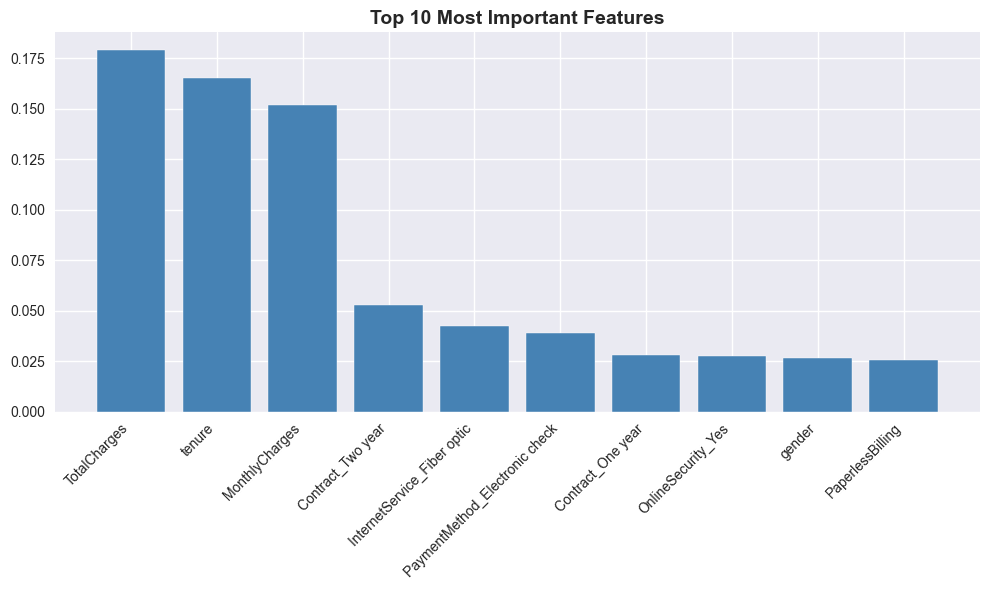

Top 5 Features:
1. TotalCharges: 0.1790
2. tenure: 0.1653
3. MonthlyCharges: 0.1520
4. Contract_Two year: 0.0527
5. InternetService_Fiber optic: 0.0426


In [106]:
rf_model = models_b['Random Forest']
importances = rf_model.feature_importances_
feature_names = X.columns
indices = np.argsort(importances)[::-1][:10]

plt.figure(figsize=(10, 6))
plt.bar(range(10), importances[indices], color='steelblue', edgecolor='white')
plt.xticks(range(10), [feature_names[i] for i in indices], 
           rotation=45, ha='right')
plt.title('Top 10 Most Important Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("Top 5 Features:")
for i in range(5):
    print(f"{i+1}. {feature_names[indices[i]]}: {importances[indices[i]]:.4f}")

# Customer Churn Prediction

Predicting which telecom customers will leave using Machine Learning.

## Problem Statement
Customer churn costs telecom companies millions annually. 
This project identifies at-risk customers so retention teams 
can take proactive action.

## Dataset
Telco Customer Churn — 7,043 customers, 21 features
Source: Kaggle

## Results
| Model | F1 Score | Recall |
|-------|----------|--------|
| Decision Tree | 0.617 | 0.807 |
| Logistic Regression | 0.613 | 0.780 |
| XGBoost | 0.599 | 0.679 |
| Random Forest | 0.597 | 0.655 |

Best model catches 80% of actual churners.

## Key Findings
- Month-to-month customers churn 3x more than 2-year contract customers
- 60% of churn happens within first 10 months
- Churned customers pay $15 more monthly on average

## Tech Stack
Python, Pandas, Scikit-learn, XGBoost, Matplotlib, Seaborn

## Project Summary

**Best Model:** Decision Tree (F1: 0.617, Recall: 0.807)
Catches 80% of actual churners.

**Business Recommendations:**
1. Target month-to-month contract customers for retention
2. Focus on customers in first 10 months — highest churn risk
3. Offer discounts to high monthly charge customers

**Why F1 Score over Accuracy:**
Dataset is imbalanced (73% No, 27% Yes).
Accuracy would be misleading — F1 balances precision and recall.